In [320]:
!pip install pandas
!pip install seaborn

In [321]:
import tensorflow as tf
from tensorflow import keras

In [322]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [323]:
import pickle

In [324]:
with open("/Users/gautam/Desktop/Erdos project repo/fall-2025-forecasting-electricity-price/src/data/datasets/data_cleaned.pkl", "rb") as f:
    loaded_dfs=pickle.load(f)

In [359]:
states = ["OR", "NY", "NV", "NH", "ME", "LA", "HI", "FL", "CT"]

In [358]:
df=loaded_dfs["HI"]

In [354]:
df=df.drop(['WWW'], axis=1)

Recurrent Neural Network

In [355]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

tf.random.set_seed(42)
np.random.seed(42)

TARGET = "residential_electricity_price"

# assume df already exists
assert TARGET in df.columns and isinstance(df.index, pd.DatetimeIndex)
df = df.sort_index()

In [356]:
def seasonal_naive_series(series: pd.Series, future_idx: pd.DatetimeIndex) -> pd.Series:
    need = future_idx - pd.DateOffset(years=1)
    vals = series.reindex(need)
    if vals.isna().any():
        fallback = series.dropna().iloc[-1] if series.dropna().size else 0.0
        vals = vals.fillna(fallback)
    vals.index = future_idx
    return vals

# detect monthly freq, default MS
FREQ = pd.infer_freq(df.index) or "MS"

SPLIT_TS = pd.Timestamp("2023-12-01")
FORECAST_IDX = pd.date_range(SPLIT_TS, "2025-12-01", freq=FREQ)[1:]  # 2024-01..2025-12


In [357]:
def sarima_forecast_column(series: pd.Series,
                           forecast_idx: pd.DatetimeIndex,
                           order=(1,1,1),
                           seasonal_order=(1,1,1,12)):
    """
    Fit a small SARIMAX on the column (univariate) and forecast to forecast_idx.
    If it fails, fall back to seasonal naive.
    """
    series = series.asfreq(FREQ)
    # keep only non-NaNs up to last known date
    series = series.dropna()
    if series.empty:
        return pd.Series(index=forecast_idx, dtype=float)

    try:
        model = SARIMAX(series, order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False)
        steps = len(forecast_idx)
        fc = res.forecast(steps=steps)
        fc.index = forecast_idx
        return fc
    except Exception:
        # fallback
        return seasonal_naive_series(series, forecast_idx)

def forecast_all_exog_with_sarima(df: pd.DataFrame,
                                  target_col: str,
                                  forecast_idx: pd.DatetimeIndex) -> pd.DataFrame:
    exog_fc = pd.DataFrame(index=forecast_idx)
    num = df.select_dtypes(include=[np.number])
    for col in num.columns:
        if col == target_col:
            continue
        print(f"[SARIMA] forecasting exog column: {col}")
        exog_fc[col] = sarima_forecast_column(num[col], forecast_idx)
    return exog_fc

# run it
sarima_exog_forecasts = forecast_all_exog_with_sarima(df, TARGET, FORECAST_IDX)


[SARIMA] forecasting exog column: ALL
[SARIMA] forecasting exog column: ANT


/Users/gautam/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMA] forecasting exog column: AOR
[SARIMA] forecasting exog column: BIO
[SARIMA] forecasting exog column: BIS
[SARIMA] forecasting exog column: BIT
[SARIMA] forecasting exog column: COL
[SARIMA] forecasting exog column: COW
[SARIMA] forecasting exog column: DFO
[SARIMA] forecasting exog column: DPV
[SARIMA] forecasting exog column: FOS
[SARIMA] forecasting exog column: GEO
[SARIMA] forecasting exog column: HYC
[SARIMA] forecasting exog column: LFG
[SARIMA] forecasting exog column: MLG
[SARIMA] forecasting exog column: MSB
[SARIMA] forecasting exog column: NG
[SARIMA] forecasting exog column: NGO
[SARIMA] forecasting exog column: OB2
[SARIMA] forecasting exog column: OBW
[SARIMA] forecasting exog column: OOG


/Users/gautam/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMA] forecasting exog column: ORW
[SARIMA] forecasting exog column: OTH
[SARIMA] forecasting exog column: PEL
[SARIMA] forecasting exog column: PET
[SARIMA] forecasting exog column: REN
[SARIMA] forecasting exog column: RFO
[SARIMA] forecasting exog column: SPV
[SARIMA] forecasting exog column: STH
[SARIMA] forecasting exog column: SUB
[SARIMA] forecasting exog column: SUN
[SARIMA] forecasting exog column: TPV
[SARIMA] forecasting exog column: TSN
[SARIMA] forecasting exog column: WAS
[SARIMA] forecasting exog column: WND
[SARIMA] forecasting exog column: WNT
[SARIMA] forecasting exog column: WOO
[SARIMA] forecasting exog column: data_center_employment
[SARIMA] forecasting exog column: coal_price
[SARIMA] forecasting exog column: net_interstate_trade
[SARIMA] forecasting exog column: total_elect_indust
[SARIMA] forecasting exog column: total_international_exports
[SARIMA] forecasting exog column: total_international_imports
[SARIMA] forecasting exog column: total_net_generation


In [346]:
def make_1step_dataset(df: pd.DataFrame,
                       target_col: str,
                       split_ts: pd.Timestamp,
                       lookback: int = 24,
                       batch_size: int = 64):
    # numeric only
    num = df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    assert target_col in num.columns

    # train range
    train_df = num.loc[:split_ts].copy()

    # scale on train only
    mu = train_df.mean()
    sd = train_df.std().replace(0, 1.0)

    num_n = ((num - mu) / sd).fillna(method="ffill").fillna(method="bfill")
    data = num_n.to_numpy(dtype=np.float32)

    # target index in columns
    cols = num.columns.tolist()
    tgt_idx = cols.index(target_col)

    # create dataset on the whole normalized array, but we only care about samples ≤ split_ts
    ds_all = tf.keras.preprocessing.timeseries_dataset_from_array(
        data=data[:-1],  # x at t
        targets=data[1:, tgt_idx],  # target at t+1 (normalized)
        sequence_length=lookback,
        sequence_stride=1,
        shuffle=True,
        batch_size=batch_size,
    )

    return ds_all, mu, sd, cols, num_n

LOOKBACK = 24
train_ds, mu, sd, COLS, df_norm = make_1step_dataset(
    df, TARGET, SPLIT_TS, lookback=LOOKBACK, batch_size=64
)


/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_22789/1543000534.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  num_n = ((num - mu) / sd).fillna(method="ffill").fillna(method="bfill")


In [347]:
def build_1step_gru(n_features, lookback=24):
    model = keras.Sequential([
        keras.layers.Input(shape=(lookback, n_features)),
        keras.layers.GRU(64, return_sequences=False),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1)  # predict normalized target
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=[keras.metrics.MeanAbsoluteError()])
    return model

nn_model = build_1step_gru(n_features=len(COLS), lookback=LOOKBACK)

es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
hist = nn_model.fit(train_ds, epochs=120, callbacks=[es], verbose=2)


Epoch 1/120
5/5 - 1s - 160ms/step - loss: 0.6209 - mean_absolute_error: 0.5566
Epoch 2/120
5/5 - 0s - 9ms/step - loss: 0.2924 - mean_absolute_error: 0.4431
Epoch 3/120
5/5 - 0s - 9ms/step - loss: 0.1704 - mean_absolute_error: 0.3058
Epoch 4/120
5/5 - 0s - 9ms/step - loss: 0.1170 - mean_absolute_error: 0.2442
Epoch 5/120
5/5 - 0s - 8ms/step - loss: 0.0908 - mean_absolute_error: 0.2180
Epoch 6/120


/Users/gautam/miniconda3/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error
  current = self.get_monitor_value(logs)


5/5 - 0s - 9ms/step - loss: 0.0732 - mean_absolute_error: 0.2031
Epoch 7/120
5/5 - 0s - 9ms/step - loss: 0.0613 - mean_absolute_error: 0.1835
Epoch 8/120
5/5 - 0s - 9ms/step - loss: 0.0568 - mean_absolute_error: 0.1750
Epoch 9/120
5/5 - 0s - 8ms/step - loss: 0.0500 - mean_absolute_error: 0.1615
Epoch 10/120
5/5 - 0s - 9ms/step - loss: 0.0452 - mean_absolute_error: 0.1535
Epoch 11/120
5/5 - 0s - 9ms/step - loss: 0.0394 - mean_absolute_error: 0.1404
Epoch 12/120
5/5 - 0s - 8ms/step - loss: 0.0356 - mean_absolute_error: 0.1335
Epoch 13/120
5/5 - 0s - 8ms/step - loss: 0.0334 - mean_absolute_error: 0.1292
Epoch 14/120
5/5 - 0s - 9ms/step - loss: 0.0315 - mean_absolute_error: 0.1235
Epoch 15/120
5/5 - 0s - 8ms/step - loss: 0.0292 - mean_absolute_error: 0.1183
Epoch 16/120
5/5 - 0s - 9ms/step - loss: 0.0282 - mean_absolute_error: 0.1150
Epoch 17/120
5/5 - 0s - 8ms/step - loss: 0.0263 - mean_absolute_error: 0.1089
Epoch 18/120
5/5 - 0s - 11ms/step - loss: 0.0271 - mean_absolute_error: 0.1101
E

In [348]:
# start window = last `LOOKBACK` rows BEFORE 2024-01
win_idx = pd.date_range(end=SPLIT_TS, periods=LOOKBACK, freq=FREQ)
window_norm = df_norm.reindex(win_idx).to_numpy(dtype=np.float32)

tgt_mu = float(mu[TARGET])
tgt_sd = float(sd[TARGET])

forecast_vals = []

# last actual target in ORIGINAL units
last_target_level = float(df.loc[SPLIT_TS, TARGET])

for ts in FORECAST_IDX:
    # build input window is already in window_norm
    # predict next TARGET (normalized)
    yhat_norm = float(nn_model.predict(window_norm[np.newaxis, ...], verbose=0).squeeze())
    yhat_level = yhat_norm * tgt_sd + tgt_mu  # de-normalize target

    forecast_vals.append(yhat_level)

    # build next feature row (ORIGINAL units first)
    row_orig = {}

    # 1) exogenous from SARIMA
    for c in sarima_exog_forecasts.columns:
        row_orig[c] = float(sarima_exog_forecasts.loc[ts, c])

    # 2) target = NN prediction
    row_orig[TARGET] = yhat_level

    # Now normalize to feed back into the window
    next_row_norm = []
    for c in COLS:
        val = row_orig.get(c, np.nan)
        # if any NaN (e.g. column wasn’t SARIMA’d), fallback to last window value
        if pd.isna(val):
            # last value from window (already normalized)
            val_norm = window_norm[-1, COLS.index(c)]
        else:
            val_norm = (val - float(mu[c])) / float(sd[c])
        next_row_norm.append(val_norm)

    next_row_norm = np.array(next_row_norm, dtype=np.float32)

    # slide window
    window_norm = np.vstack([window_norm[1:], next_row_norm])

    # update last_target_level (not strictly needed since we’re using yhat directly)
    last_target_level = yhat_level

# Assemble output
nn_forecast = pd.Series(forecast_vals, index=FORECAST_IDX, name="forecast")
actual_future = df[TARGET].reindex(FORECAST_IDX).rename("actual")
out = pd.concat([nn_forecast, actual_future], axis=1)
out.head()


,forecast,actual
2024-01-01,25.787503,27.41
2024-02-01,26.563384,29.52
2024-03-01,26.316117,29.12
2024-04-01,24.697776,29.57
2024-05-01,25.403343,26.73


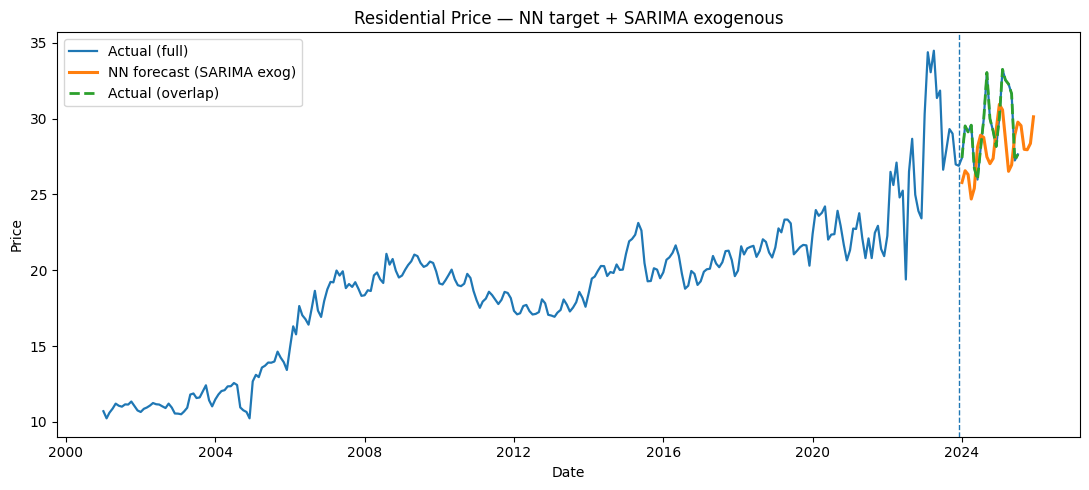

{'MAE_overlap_2024-01_to_2025-07': 2.6806230027047784, 'RMSE_overlap_2024-01_to_2025-07': 3.08764923569991}


In [349]:
plt.figure(figsize=(11,5))

# actual full history
plt.plot(df[TARGET].index, df[TARGET].values, label="Actual (full)", linewidth=1.6)

# forecast (2024-01..2025-12)
plt.plot(out.index, out["forecast"], label="NN forecast (SARIMA exog)", linewidth=2.2)

# dashed actual in overlap
overlap = out.dropna(subset=["actual"]).loc["2024-01-01":"2025-07-01"]
if not overlap.empty:
    plt.plot(overlap.index, overlap["actual"], "--", label="Actual (overlap)", linewidth=2)

plt.axvline(SPLIT_TS, linestyle="--", linewidth=1)
plt.title("Residential Price — NN target + SARIMA exogenous")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.tight_layout()
plt.show()

# quick overlap metrics
if not overlap.empty:
    e = out["forecast"].reindex(overlap.index) - overlap["actual"]
    mae  = float(np.mean(np.abs(e)))
    rmse = float(np.sqrt(np.mean(e**2)))
    print({"MAE_overlap_2024-01_to_2025-07": mae, "RMSE_overlap_2024-01_to_2025-07": rmse})
else:
    print("No overlap actuals to score.")


In [367]:
tf.random.set_seed(42)
np.random.seed(42)

TARGET = "residential_electricity_price"
SPLIT_TS = pd.Timestamp("2023-12-01")  # same as your code


In [368]:
def seasonal_naive_series(series: pd.Series, future_idx: pd.DatetimeIndex) -> pd.Series:
    need = future_idx - pd.DateOffset(years=1)
    vals = series.reindex(need)
    if vals.isna().any():
        fallback = series.dropna().iloc[-1] if series.dropna().size else 0.0
        vals = vals.fillna(fallback)
    vals.index = future_idx
    return vals


def sarima_forecast_column(series: pd.Series,
                           forecast_idx: pd.DatetimeIndex,
                           freq: str,
                           order=(1,1,1),
                           seasonal_order=(1,1,1,12)):
    series = series.asfreq(freq)
    series = series.dropna()
    if series.empty:
        return pd.Series(index=forecast_idx, dtype=float)

    try:
        model = SARIMAX(series, order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        res = model.fit(disp=False)
        steps = len(forecast_idx)
        fc = res.forecast(steps=steps)
        fc.index = forecast_idx
        return fc
    except Exception:
        return seasonal_naive_series(series, forecast_idx)


def forecast_all_exog_with_sarima(df: pd.DataFrame,
                                  target_col: str,
                                  forecast_idx: pd.DatetimeIndex,
                                  freq: str) -> pd.DataFrame:
    exog_fc = pd.DataFrame(index=forecast_idx)
    num = df.select_dtypes(include=[np.number])
    for col in num.columns:
        if col == target_col:
            continue
        print(f"[SARIMA] forecasting exog column: {col}")
        exog_fc[col] = sarima_forecast_column(num[col], forecast_idx, freq=freq)
    return exog_fc


def make_1step_dataset(df: pd.DataFrame,
                       target_col: str,
                       split_ts: pd.Timestamp,
                       lookback: int = 24,
                       batch_size: int = 64):
    # numeric only
    num = df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
    assert target_col in num.columns

    # train range
    train_df = num.loc[:split_ts].copy()

    # scale on train only
    mu = train_df.mean()
    sd = train_df.std().replace(0, 1.0)

    num_n = ((num - mu) / sd).fillna(method="ffill").fillna(method="bfill")
    data = num_n.to_numpy(dtype=np.float32)

    cols = num.columns.tolist()
    tgt_idx = cols.index(target_col)

    ds_all = tf.keras.preprocessing.timeseries_dataset_from_array(
        data=data[:-1],                   # x at t
        targets=data[1:, tgt_idx],        # y = target at t+1
        sequence_length=lookback,
        sequence_stride=1,
        shuffle=True,
        batch_size=batch_size,
    )

    return ds_all, mu, sd, cols, num_n


def build_1step_gru(n_features, lookback=24):
    model = keras.Sequential([
        keras.layers.Input(shape=(lookback, n_features)),
        keras.layers.GRU(64, return_sequences=False),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1)  # predict normalized target
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="mse",
                  metrics=[keras.metrics.MeanAbsoluteError()])
    return model


In [369]:
LOOKBACK = 24

# to store outputs per state
all_forecasts = {}
all_overlap_scores = {}

for st in states:
    print(f"\n================= {st} =================")

    # 1) get and clean df
    df = loaded_dfs[st].copy()
    if "WWW" in df.columns:
        df = df.drop(["WWW"], axis=1)

    # make sure target and datetime index
    assert TARGET in df.columns, f"{TARGET} not in {st}"
    assert isinstance(df.index, pd.DatetimeIndex), f"Index not datetime for {st}"
    df = df.sort_index()

    # 2) freq + forecast index (same dates as your code)
    FREQ = pd.infer_freq(df.index) or "MS"
    FORECAST_IDX = pd.date_range(SPLIT_TS, "2025-12-01", freq=FREQ)[1:]

    # 3) SARIMA forecasts for exog
    sarima_exog_forecasts = forecast_all_exog_with_sarima(df, TARGET, FORECAST_IDX, FREQ)

    # 4) dataset + scaling for NN
    train_ds, mu, sd, COLS, df_norm = make_1step_dataset(
        df, TARGET, SPLIT_TS, lookback=LOOKBACK, batch_size=64
    )

    # 5) build + train NN
    nn_model = build_1step_gru(n_features=len(COLS), lookback=LOOKBACK)
    es = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    nn_model.fit(train_ds, epochs=120, callbacks=[es], verbose=0)

    # 6) roll forward just like your original code
    # start window = last LOOKBACK rows before split
    win_idx = pd.date_range(end=SPLIT_TS, periods=LOOKBACK, freq=FREQ)
    window_norm = df_norm.reindex(win_idx).to_numpy(dtype=np.float32)

    tgt_mu = float(mu[TARGET])
    tgt_sd = float(sd[TARGET])

    forecast_vals = []

    for ts in FORECAST_IDX:
        # predict next normalized target
        yhat_norm = float(nn_model.predict(window_norm[np.newaxis, ...], verbose=0).squeeze())
        yhat_level = yhat_norm * tgt_sd + tgt_mu
        forecast_vals.append(yhat_level)

        # build next row in ORIGINAL units
        row_orig = {}
        # exogenous from SARIMA
        for c in sarima_exog_forecasts.columns:
            row_orig[c] = float(sarima_exog_forecasts.loc[ts, c])
        # target = prediction
        row_orig[TARGET] = yhat_level

        # normalize next row to feed back
        next_row_norm = []
        for c in COLS:
            val = row_orig.get(c, np.nan)
            if pd.isna(val):
                # fallback to last value in window
                val_norm = window_norm[-1, COLS.index(c)]
            else:
                val_norm = (val - float(mu[c])) / float(sd[c])
            next_row_norm.append(val_norm)
        next_row_norm = np.array(next_row_norm, dtype=np.float32)

        # slide window
        window_norm = np.vstack([window_norm[1:], next_row_norm])

    # 7) assemble output for this state
    nn_forecast = pd.Series(forecast_vals, index=FORECAST_IDX, name="forecast")
    actual_future = df[TARGET].reindex(FORECAST_IDX).rename("actual")
    out = pd.concat([nn_forecast, actual_future], axis=1)

    # store
    all_forecasts[st] = out

    # 8) quick overlap metrics (like your code)
    overlap = out.dropna(subset=["actual"]).loc["2024-01-01":"2025-07-01"]
    if not overlap.empty:
        e = out["forecast"].reindex(overlap.index) - overlap["actual"]
        mae  = float(np.mean(np.abs(e)))
        rmse = float(np.sqrt(np.mean(e**2)))
        all_overlap_scores[st] = {
            "MAE_overlap_2024-01_to_2025-07": mae,
            "RMSE_overlap_2024-01_to_2025-07": rmse,
        }
        print(st, all_overlap_scores[st])
    else:
        all_overlap_scores[st] = None
        print(st, "No overlap actuals to score.")



================= OR =================
[SARIMA] forecasting exog column: ALL
[SARIMA] forecasting exog column: ANT


/Users/gautam/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMA] forecasting exog column: AOR
[SARIMA] forecasting exog column: BIO
[SARIMA] forecasting exog column: BIS
[SARIMA] forecasting exog column: BIT
[SARIMA] forecasting exog column: COL
[SARIMA] forecasting exog column: COW
[SARIMA] forecasting exog column: DFO
[SARIMA] forecasting exog column: DPV
[SARIMA] forecasting exog column: FOS
[SARIMA] forecasting exog column: GEO
[SARIMA] forecasting exog column: HYC
[SARIMA] forecasting exog column: LFG
[SARIMA] forecasting exog column: MLG
[SARIMA] forecasting exog column: MSB
[SARIMA] forecasting exog column: NG
[SARIMA] forecasting exog column: NGO
[SARIMA] forecasting exog column: OB2
[SARIMA] forecasting exog column: OBW
[SARIMA] forecasting exog column: OOG


/Users/gautam/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMA] forecasting exog column: ORW
[SARIMA] forecasting exog column: OTH
[SARIMA] forecasting exog column: PEL
[SARIMA] forecasting exog column: PET
[SARIMA] forecasting exog column: REN
[SARIMA] forecasting exog column: RFO
[SARIMA] forecasting exog column: SPV
[SARIMA] forecasting exog column: STH
[SARIMA] forecasting exog column: SUB
[SARIMA] forecasting exog column: SUN
[SARIMA] forecasting exog column: TPV
[SARIMA] forecasting exog column: TSN
[SARIMA] forecasting exog column: WAS
[SARIMA] forecasting exog column: WND
[SARIMA] forecasting exog column: WNT
[SARIMA] forecasting exog column: WOO
[SARIMA] forecasting exog column: data_center_employment
[SARIMA] forecasting exog column: coal_price
[SARIMA] forecasting exog column: net_interstate_trade
[SARIMA] forecasting exog column: total_elect_indust
[SARIMA] forecasting exog column: total_international_exports
[SARIMA] forecasting exog column: total_international_imports
[SARIMA] forecasting exog column: total_net_generation


...

[SARIMA] forecasting exog column: PEL
[SARIMA] forecasting exog column: PET
[SARIMA] forecasting exog column: REN
[SARIMA] forecasting exog column: RFO
[SARIMA] forecasting exog column: SPV
[SARIMA] forecasting exog column: SUB
[SARIMA] forecasting exog column: SUN
[SARIMA] forecasting exog column: TPV
[SARIMA] forecasting exog column: TSN
[SARIMA] forecasting exog column: WAS
[SARIMA] forecasting exog column: WND


/Users/gautam/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[SARIMA] forecasting exog column: WNT
[SARIMA] forecasting exog column: WOO
[SARIMA] forecasting exog column: data_center_employment
[SARIMA] forecasting exog column: net_interstate_trade
[SARIMA] forecasting exog column: total_elect_indust
[SARIMA] forecasting exog column: total_international_exports
[SARIMA] forecasting exog column: total_international_imports
[SARIMA] forecasting exog column: total_net_generation


/var/folders/4p/f13_3n_91_b8f3l9jyg_yphh0000gn/T/ipykernel_22789/810239899.py:65: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  num_n = ((num - mu) / sd).fillna(method="ffill").fillna(method="bfill")
/Users/gautam/miniconda3/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error
  current = self.get_monitor_value(logs)


CT {'MAE_overlap_2024-01_to_2025-07': 3.4894487193336934, 'RMSE_overlap_2024-01_to_2025-07': 4.1196480267049935}


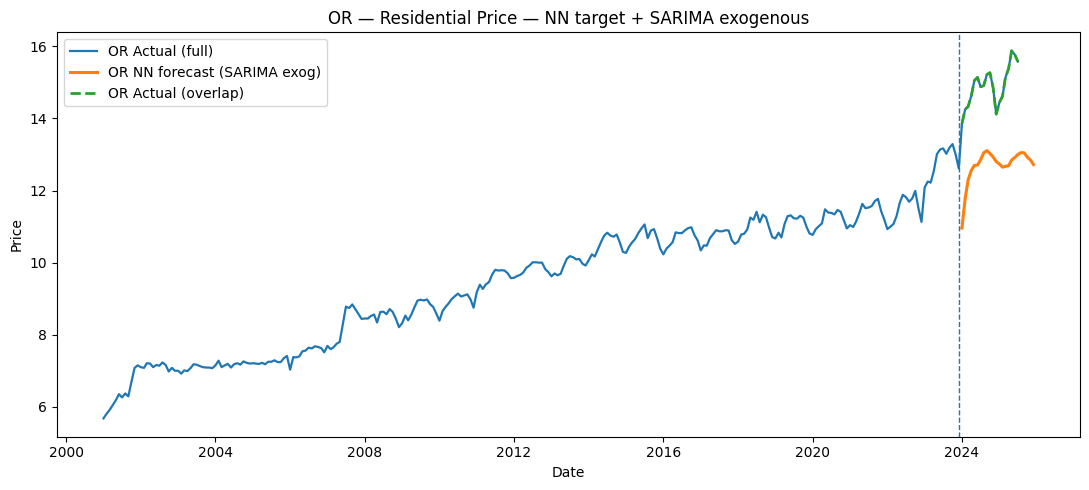

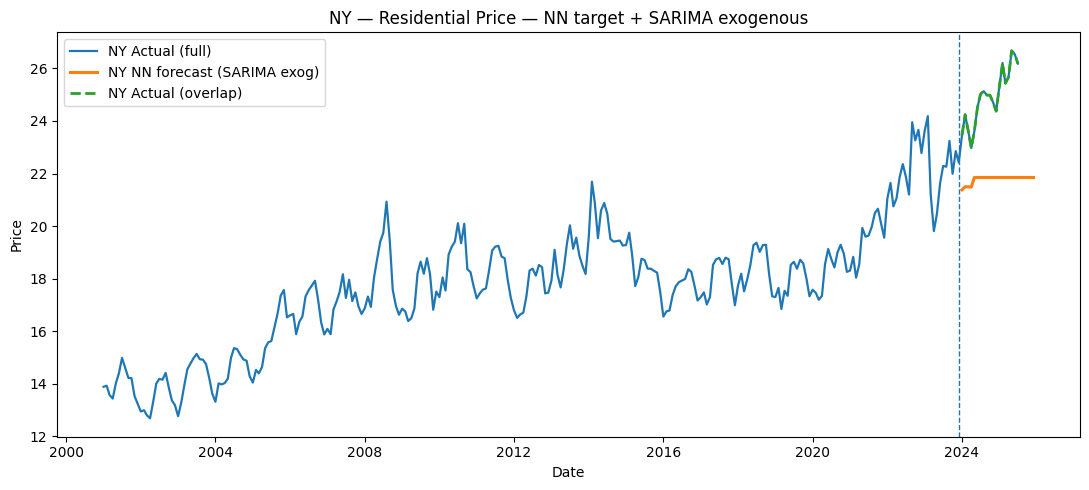

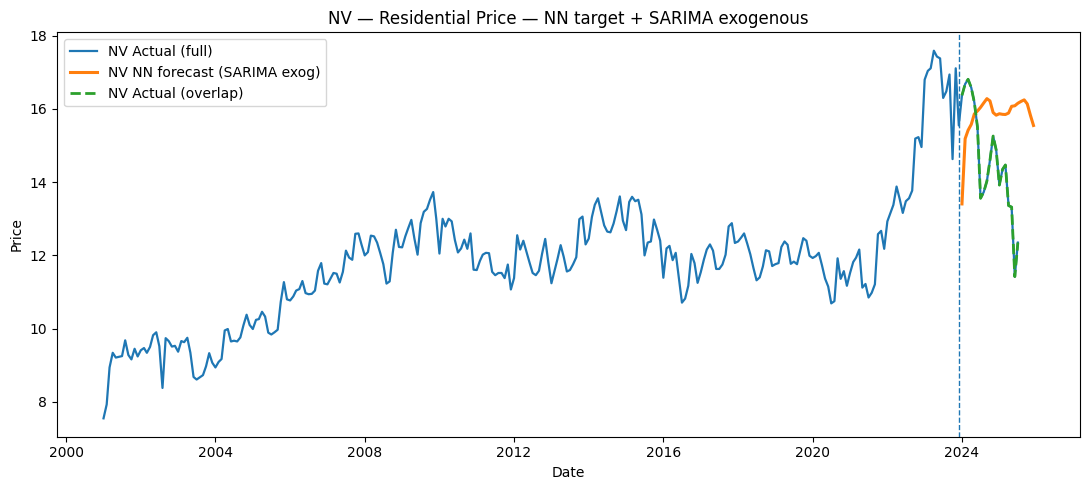

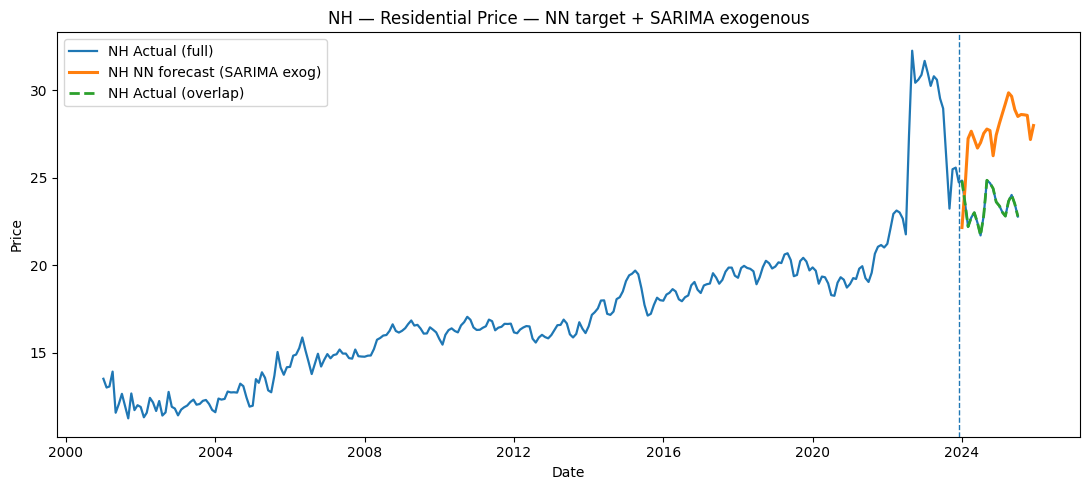

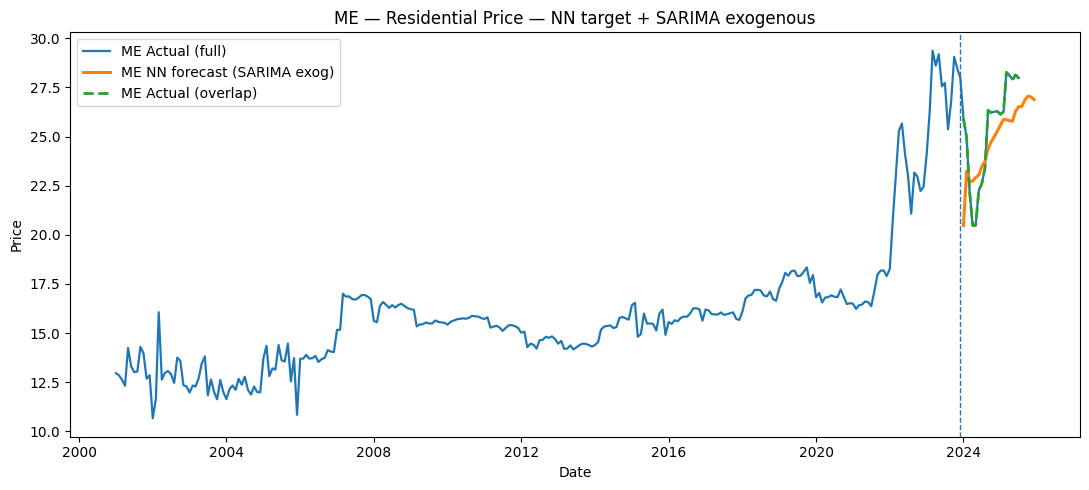

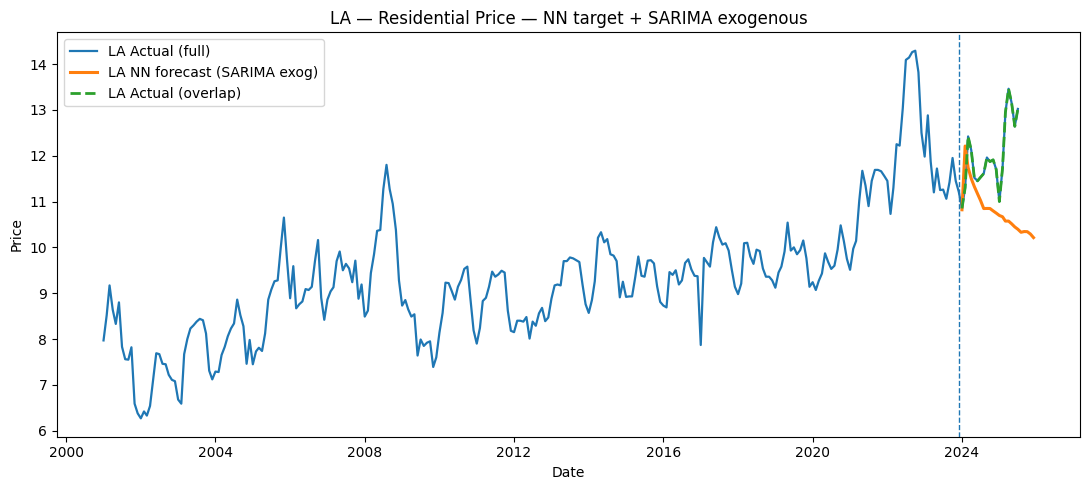

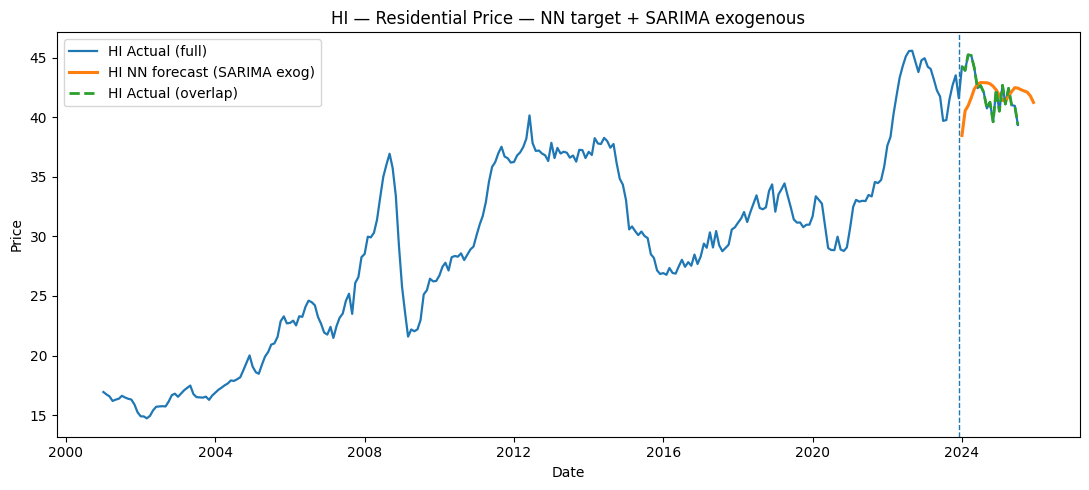

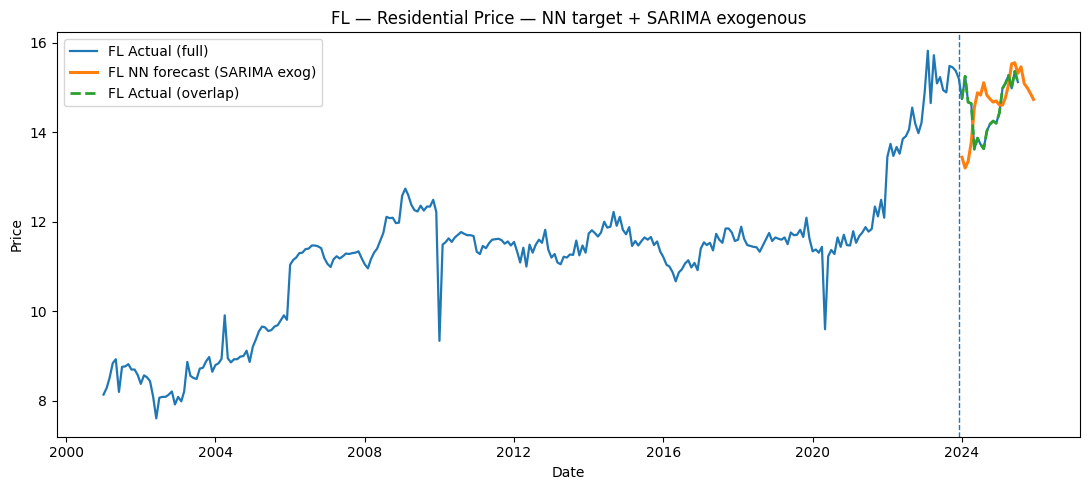

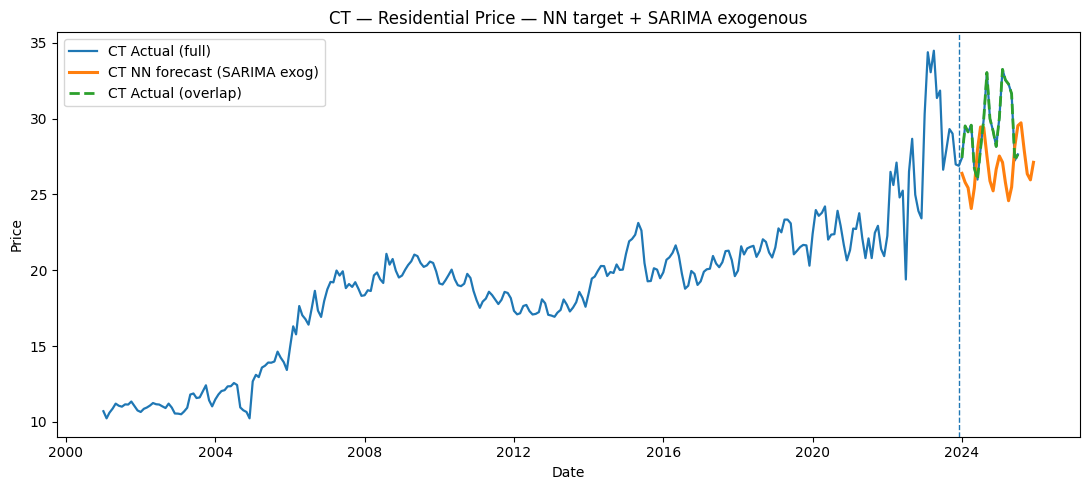

In [370]:
for st in states:
    out = all_forecasts[st]
    df = loaded_dfs[st]
    if "WWW" in df.columns:
        df = df.drop(["WWW"], axis=1)
    df = df.sort_index()

    plt.figure(figsize=(11,5))
    plt.plot(df[TARGET].index, df[TARGET].values, label=f"{st} Actual (full)", linewidth=1.6)
    plt.plot(out.index, out["forecast"], label=f"{st} NN forecast (SARIMA exog)", linewidth=2.2)

    overlap = out.dropna(subset=["actual"]).loc["2024-01-01":"2025-07-01"]
    if not overlap.empty:
        plt.plot(overlap.index, overlap["actual"], "--", label=f"{st} Actual (overlap)", linewidth=2)

    plt.axvline(SPLIT_TS, linestyle="--", linewidth=1)
    plt.title(f"{st} — Residential Price — NN target + SARIMA exogenous")
    plt.xlabel("Date"); plt.ylabel("Price")
    plt.legend(); plt.tight_layout()
    plt.show()
